In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 1 — Setup, Drive Mount, Safe Kaggle Config
# ════════════════════════════════════════════════════════════════
import os, json, random
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from getpass import getpass

# Mount Drive
drive.mount("/content/drive")

# Paths (new folder, not under MedIA_Research)
DRIVE_ROOT = "/content/drive/MyDrive"
DATA_ROOT  = f"{DRIVE_ROOT}/datasets/sipakmed"      # raw/unzipped
WORK_ROOT  = f"{DRIVE_ROOT}/projects/sipakmed_demo" # notebooks/results
os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(WORK_ROOT, exist_ok=True)

# Safe Kaggle auth: type at runtime (won't be printed)
os.environ["KAGGLE_USERNAME"] = input("Kaggle username: ")
os.environ["KAGGLE_KEY"] = getpass("Kaggle API key (input hidden): ")

os.makedirs("/root/.config/kaggle", exist_ok=True)
with open("/root/.config/kaggle/kaggle.json", "w") as f:
    json.dump({"username": os.environ["KAGGLE_USERNAME"], "key": os.environ["KAGGLE_KEY"]}, f)
os.system("chmod 600 /root/.config/kaggle/kaggle.json")

# Seeds (good practice)
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print("DATA_ROOT:", DATA_ROOT)
print("WORK_ROOT:", WORK_ROOT)
print("Cell 1 complete.")

Mounted at /content/drive
Kaggle username: Apoorv2006
Kaggle API key (input hidden): ··········
DATA_ROOT: /content/drive/MyDrive/datasets/sipakmed
WORK_ROOT: /content/drive/MyDrive/projects/sipakmed_demo
Cell 1 complete.


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 2 — Download SIPaKMeD (skip if already downloaded)
# ════════════════════════════════════════════════════════════════
!pip -q install kaggle

DATASET_SLUG = "prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed"

# If folder is empty, download; otherwise skip
if len(os.listdir(DATA_ROOT)) == 0:
    !kaggle datasets download -d {DATASET_SLUG} --path "{DATA_ROOT}" --unzip
    print("Download complete.")
else:
    print("DATA_ROOT not empty → assuming dataset already downloaded. Skipping download.")

Dataset URL: https://www.kaggle.com/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed
License(s): other
100% 6.40G/6.40G [00:45<00:00, 153MB/s]

Download complete.


In [ ]:
# ════════════════════════════════════════════════════════════════
# CELL 3 — Inspect dataset structure (important)
# ════════════════════════════════════════════════════════════════
import os

for root, dirs, files in os.walk(DATA_ROOT):
    depth = root.replace(DATA_ROOT, "").count(os.sep)
    if depth <= 2:
        print(root, "| dirs:", dirs[:10], "| files:", files[:10])

/content/drive/MyDrive/datasets/sipakmed | dirs: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate'] | files: []
/content/drive/MyDrive/datasets/sipakmed/im_Dyskeratotic | dirs: ['im_Dyskeratotic'] | files: []
/content/drive/MyDrive/datasets/sipakmed/im_Dyskeratotic/im_Dyskeratotic | dirs: ['CROPPED'] | files: ['001.bmp', '001_cyt01.dat', '001_cyt02.dat', '001_cyt03.dat', '001_cyt04.dat', '001_cyt05.dat', '001_nuc01.dat', '001_nuc02.dat', '001_nuc03.dat', '001_nuc04.dat']
/content/drive/MyDrive/datasets/sipakmed/im_Koilocytotic | dirs: ['im_Koilocytotic'] | files: []
/content/drive/MyDrive/datasets/sipakmed/im_Koilocytotic/im_Koilocytotic | dirs: ['CROPPED'] | files: ['001.bmp', '001_cyt01.dat', '001_nuc01.dat', '002.bmp', '002_cyt01.dat', '002_nuc01.dat', '003.bmp', '003_cyt01.dat', '003_nuc01.dat', '004.bmp']
/content/drive/MyDrive/datasets/sipakmed/im_Metaplastic | dirs: ['im_Metaplastic'] | files: []
/content/drive/MyDrive/dataset

In [ ]:
import os, glob
import pandas as pd

DATA_ROOT = "/content/drive/MyDrive/datasets/sipakmed"

CLASS_DIRS = {
    "Dyskeratotic": "im_Dyskeratotic/im_Dyskeratotic/CROPPED",
    "Koilocytotic": "im_Koilocytotic/im_Koilocytotic/CROPPED",
    "Metaplastic": "im_Metaplastic/im_Metaplastic/CROPPED",
    "Parabasal": "im_Parabasal/im_Parabasal/CROPPED",
    "Superficial-Intermediate": "im_Superficial-Intermediate/im_Superficial-Intermediate/CROPPED",
}

rows = []
for cls, rel in CLASS_DIRS.items():
    folder = os.path.join(DATA_ROOT, rel)
    files = sorted(glob.glob(os.path.join(folder, "*.bmp")))
    for fp in files:
        rows.append({"path": fp, "orig_class": cls})

df = pd.DataFrame(rows)
print("Total images:", len(df))
df["orig_class"].value_counts()

Total images: 4049


,count
orig_class,
Superficial-Intermediate,831
Koilocytotic,825
Dyskeratotic,813
Metaplastic,793
Parabasal,787


In [ ]:
from sklearn.model_selection import train_test_split

abnormal = {"Dyskeratotic", "Koilocytotic"}
df["label"] = df["orig_class"].apply(lambda c: 1 if c in abnormal else 0)

print("Binary label distribution:\n", df["label"].value_counts())

# 70/15/15 split (stratified)
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df["label"])
val_df, test_df   = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df["label"])

len(train_df), len(val_df), len(test_df), train_df["label"].mean(), val_df["label"].mean(), test_df["label"].mean()

Binary label distribution:
 label
0    2411
1    1638
Name: count, dtype: int64


(2834,
 607,
 608,
 np.float64(0.4043754410726888),
 np.float64(0.4052718286655684),
 np.float64(0.40460526315789475))

In [ ]:
import shutil
from tqdm import tqdm

PREP_ROOT = "/content/drive/MyDrive/datasets/sipakmed_prepared_binary"

def make_dirs():
    for split in ["train", "val", "test"]:
        for cls in ["negative", "positive"]:
            os.makedirs(os.path.join(PREP_ROOT, split, cls), exist_ok=True)

def copy_split(split_df, split_name):
    for _, r in tqdm(split_df.iterrows(), total=len(split_df), desc=f"Copy {split_name}"):
        src = r["path"]
        cls = "positive" if r["label"] == 1 else "negative"
        # make unique filename: include orig class + basename
        dst_name = f'{r["orig_class"]}__{os.path.basename(src)}'
        dst = os.path.join(PREP_ROOT, split_name, cls, dst_name)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)

make_dirs()
copy_split(train_df, "train")
copy_split(val_df, "val")
copy_split(test_df, "test")

print("Prepared dataset saved at:", PREP_ROOT)


Copy test: 100%|██████████| 608/608 [00:13<00:00, 45.70it/s]

Prepared dataset saved at: /content/drive/MyDrive/datasets/sipakmed_prepared_binary


In [ ]:
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = ImageFolder(os.path.join(PREP_ROOT, "train"), transform=train_tfms)
val_ds   = ImageFolder(os.path.join(PREP_ROOT, "val"), transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print("Classes:", train_ds.classes)
print("Class->idx:", train_ds.class_to_idx)
x, y = next(iter(train_loader))
print("Batch shapes:", x.shape, y.shape, "min/max:", x.min().item(), x.max().item())

Classes: ['negative', 'positive']
Class->idx: {'negative': 0, 'positive': 1}
Batch shapes: torch.Size([32, 3, 224, 224]) torch.Size([32]) min/max: -2.1179039478302 2.640000104904175


['positive', 'negative', 'negative', 'negative', 'negative', 'positive', 'negative', 'positive', 'positive', 'negative', 'positive', 'negative', 'negative', 'positive', 'negative', 'positive']


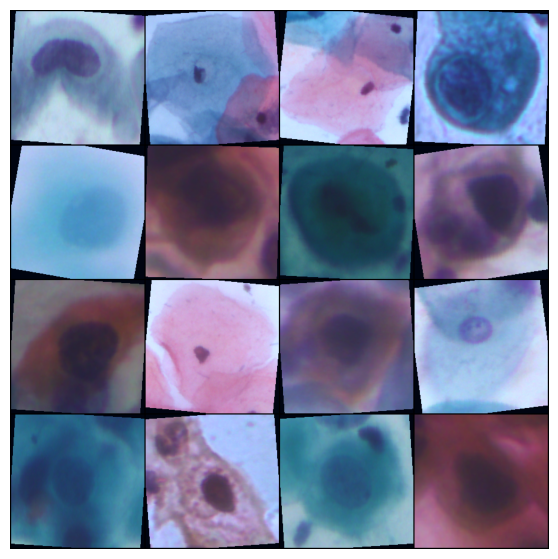

In [ ]:
import torchvision
import matplotlib.pyplot as plt

def show_batch(images, labels, classes, n=16):
    images = images[:n].cpu()
    labels = labels[:n].cpu()
    grid = torchvision.utils.make_grid(images, nrow=4, normalize=True)
    plt.figure(figsize=(7,7))
    plt.imshow(grid.permute(1,2,0))
    plt.axis("off")
    print([classes[i] for i in labels.numpy()])
    plt.show()

show_batch(x, y, train_ds.classes)

In [ ]:
SPLIT_DIR = "/content/drive/MyDrive/datasets/sipakmed_splits"
os.makedirs(SPLIT_DIR, exist_ok=True)

train_df.to_csv(f"{SPLIT_DIR}/train.csv", index=False)
val_df.to_csv(f"{SPLIT_DIR}/val.csv", index=False)
test_df.to_csv(f"{SPLIT_DIR}/test.csv", index=False)

print("Saved splits to:", SPLIT_DIR)

Saved splits to: /content/drive/MyDrive/datasets/sipakmed_splits
